# 05 — External Baseline Comparison

RAG pipeline (Phase 9, KB v2) vs **MentalRoBERTa** fine-tuned, on the same
450-post held-out evaluation set.

**Before running this notebook**, produce the baseline predictions:

```bash
python analysis/mentalroberta_baseline.py
```

Both systems are scored on identical posts, so every comparison here is
**paired** and uses McNemar's exact test from `src/evaluation/selection.py`.

### What is being compared

| | RAG pipeline | MentalRoBERTa |
|---|---|---|
| Paradigm | Retrieval-augmented generation, no task training | Supervised fine-tuning |
| Labelled data used | none for the classifier (few-shot examples only) | thousands of labelled posts |
| Output | label + citation to ICD-11 text | label + probability |
| Grounding | auditable against retrieved evidence | none |

The comparison is *not* like-for-like on training signal, and that asymmetry is
the point: it quantifies what a supervised encoder buys over a zero/few-shot
grounded system, and what is given up in return.

In [16]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             confusion_matrix, f1_score, recall_score)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.evaluation.selection import mcnemar_exact, paired_bootstrap_diff

LABELS = ["suicidal", "depression", "normal"]
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("ready")

ready


## 1. Load both systems' predictions

In [17]:
RAG_CSV  = ROOT / "results" / "phase9_run1.csv"
MRB_CSV  = ROOT / "results" / "mentalroberta_eval_predictions.csv"

rag = pd.read_csv(RAG_CSV)
mrb = pd.read_csv(MRB_CSV)

# Align on post order so the comparison is genuinely paired.
rag = rag.sort_values("post_index").reset_index(drop=True)
mrb = mrb.sort_values("post_index").reset_index(drop=True)

assert len(rag) == len(mrb), f"row mismatch: {len(rag)} vs {len(mrb)}"
assert (rag["true_label"].values == mrb["true_label"].values).all(), \
    "true labels differ — the two systems were not scored on the same posts"

y_true = rag["true_label"].values
systems = {
    "RAG pipeline (KB v2)": rag["predicted"].values,
    "MentalRoBERTa": mrb["predicted"].values,
}
print(f"{len(y_true)} posts, aligned and verified")
print(pd.Series(y_true).value_counts().to_dict())

450 posts, aligned and verified
{'suicidal': 150, 'depression': 150, 'normal': 150}


## 2. Headline metrics

Recall on the **suicidal** class is reported separately: a false negative there
removes the chance of intervention, while a false positive costs only a
redundant review.

In [18]:
rows = []
for name, y_pred in systems.items():
    rows.append({
        "System": name,
        "Accuracy": (y_pred == y_true).mean(),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Suicidal recall": recall_score(y_true, y_pred, labels=["suicidal"],
                                        average="macro", zero_division=0),
        "Unknown/parse fail": float((pd.Series(y_pred) == "unknown").mean()),
    })

summary = pd.DataFrame(rows).set_index("System").round(4)
display(summary)

,Accuracy,Macro-F1,Suicidal recall,Unknown/parse fail
System,,,,
RAG pipeline (KB v2),0.6756,0.6428,0.7933,0.0
MentalRoBERTa,0.8711,0.8705,0.8600,0.0


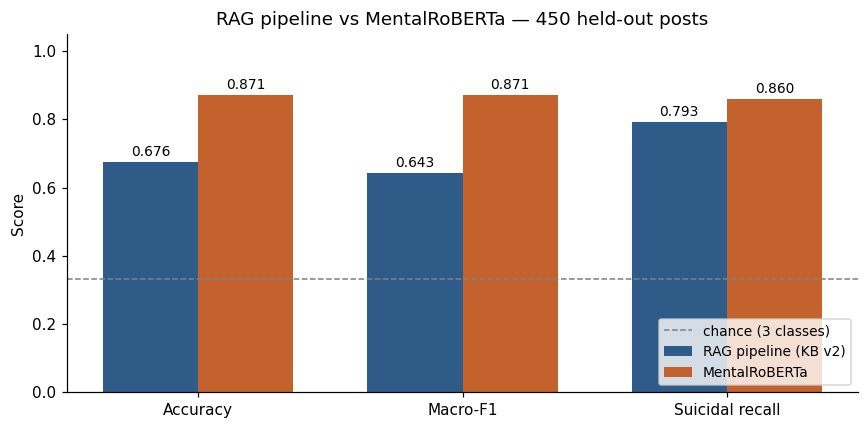

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
metrics = ["Accuracy", "Macro-F1", "Suicidal recall"]
x = np.arange(len(metrics))
width = 0.36
colors = ["#2E5B88", "#C4622D"]

for i, (name, _) in enumerate(systems.items()):
    vals = [summary.loc[name, m] for m in metrics]
    bars = ax.bar(x + (i - 0.5) * width, vals, width, label=name, color=colors[i])
    ax.bar_label(bars, fmt="%.3f", fontsize=9, padding=2)

ax.set_xticks(x, metrics)
ax.set_ylim(0, 1.05)
ax.axhline(1 / 3, ls="--", lw=1, color="grey", label="chance (3 classes)")
ax.set_ylabel("Score")
ax.set_title("RAG pipeline vs MentalRoBERTa — 450 held-out posts")
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Confusion matrices, side by side

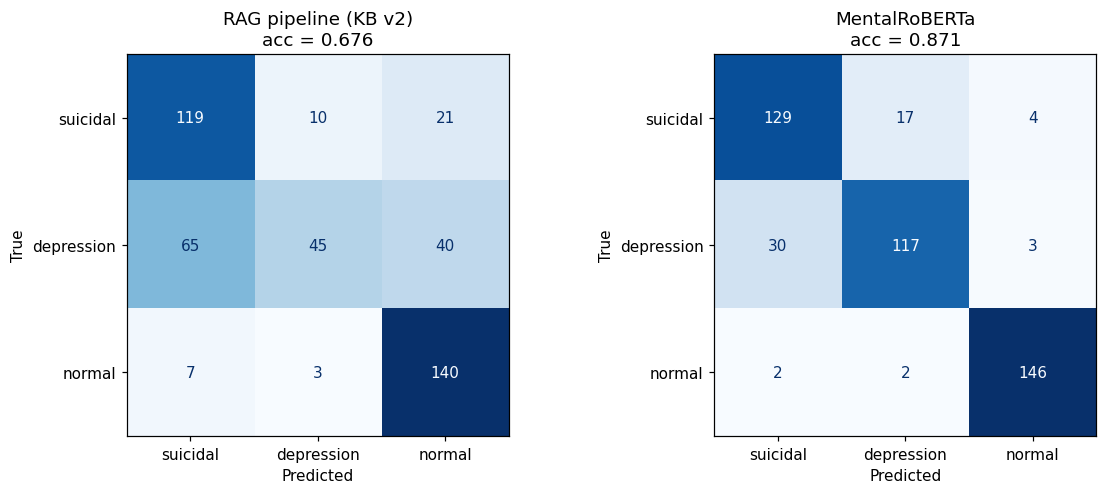

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

for ax, (name, y_pred) in zip(axes, systems.items()):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    acc = (y_pred == y_true).mean()
    ax.set_title(f"{name}\nacc = {acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

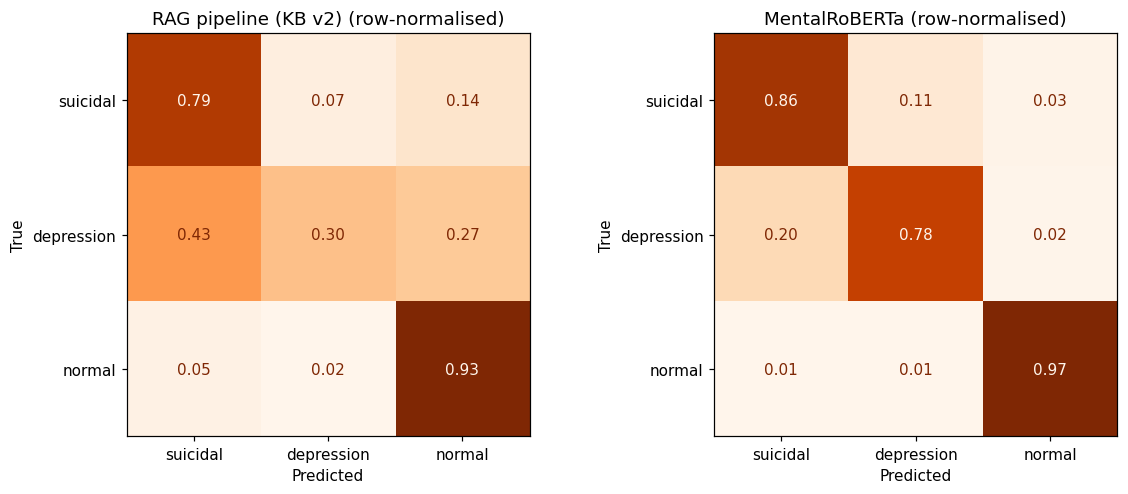

In [21]:
# Normalised by true class — makes per-class recall directly readable.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

for ax, (name, y_pred) in zip(axes, systems.items()):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS, normalize="true")
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
        ax=ax, cmap="Oranges", colorbar=False, values_format=".2f")
    ax.set_title(f"{name} (row-normalised)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

## 4. Per-class breakdown

In [22]:
for name, y_pred in systems.items():
    print(f"=== {name} ===")
    print(classification_report(y_true, y_pred, labels=LABELS,
                                digits=3, zero_division=0))

=== RAG pipeline (KB v2) ===
              precision    recall  f1-score   support

    suicidal      0.623     0.793     0.698       150
  depression      0.776     0.300     0.433       150
      normal      0.697     0.933     0.798       150

    accuracy                          0.676       450
   macro avg      0.698     0.676     0.643       450
weighted avg      0.698     0.676     0.643       450

=== MentalRoBERTa ===
              precision    recall  f1-score   support

    suicidal      0.801     0.860     0.830       150
  depression      0.860     0.780     0.818       150
      normal      0.954     0.973     0.964       150

    accuracy                          0.871       450
   macro avg      0.872     0.871     0.870       450
weighted avg      0.872     0.871     0.870       450



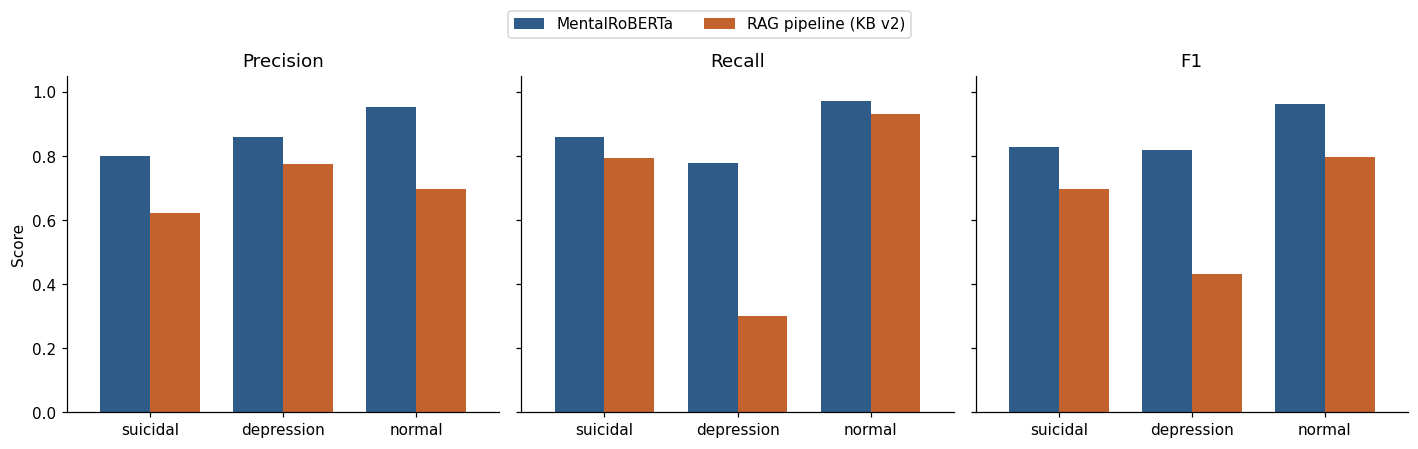

In [23]:
per_class = []
for name, y_pred in systems.items():
    rep = classification_report(y_true, y_pred, labels=LABELS,
                                output_dict=True, zero_division=0)
    for label in LABELS:
        per_class.append({"System": name, "Class": label,
                          "Precision": rep[label]["precision"],
                          "Recall": rep[label]["recall"],
                          "F1": rep[label]["f1-score"]})
pc = pd.DataFrame(per_class)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, metric in zip(axes, ["Precision", "Recall", "F1"]):
    sub = pc.pivot(index="Class", columns="System", values=metric).loc[LABELS]
    sub.plot(kind="bar", ax=ax, color=colors, width=0.75, legend=False)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Score")
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

## 5. Is the difference statistically significant?

Both systems classified the **same** 450 posts, so the outcomes are paired and
McNemar's exact test applies. Comparing two independent confidence intervals
would discard that pairing and understate the evidence.

In [24]:
rag_correct = (systems["RAG pipeline (KB v2)"] == y_true).astype(int)
mrb_correct = (systems["MentalRoBERTa"] == y_true).astype(int)

mc = mcnemar_exact(rag_correct, mrb_correct)
bs = paired_bootstrap_diff(rag_correct, mrb_correct)

print("McNemar's exact test (paired, per-post correctness)")
print(f"  RAG right / MRB wrong : {mc['n10']}")
print(f"  RAG wrong / MRB right : {mc['n01']}")
print(f"  discordant pairs      : {mc['n_discordant']}")
print(f"  p-value               : {mc['p_value']:.6f}")
print(f"  significant at 0.05   : {mc['significant']}")
print()
print("Paired bootstrap on the accuracy difference (RAG - MentalRoBERTa)")
print(f"  difference : {bs['diff']:+.4f}")
print(f"  95% CI     : [{bs['ci_lo']:+.4f}, {bs['ci_hi']:+.4f}]")
print(f"  excludes 0 : {bs['excludes_zero']}")

McNemar's exact test (paired, per-post correctness)
  RAG right / MRB wrong : 19
  RAG wrong / MRB right : 107
  discordant pairs      : 126
  p-value               : 0.000000
  significant at 0.05   : True

Paired bootstrap on the accuracy difference (RAG - MentalRoBERTa)
  difference : -0.1956
  95% CI     : [-0.2400, -0.1511]
  excludes 0 : True


In [25]:
# Same test restricted to the safety-critical class.
mask = y_true == "suicidal"
mc_s = mcnemar_exact(rag_correct[mask], mrb_correct[mask])
print(f"Suicidal class only (n={mask.sum()})")
print(f"  RAG recall : {rag_correct[mask].mean():.3f}")
print(f"  MRB recall : {mrb_correct[mask].mean():.3f}")
print(f"  McNemar p  : {mc_s['p_value']:.6f}  "
      f"(discordant {mc_s['n_discordant']})")

Suicidal class only (n=150)
  RAG recall : 0.793
  MRB recall : 0.860
  McNemar p  : 0.121449  (discordant 34)


## 6. Agreement and complementarity

Where the two systems disagree is more informative than the headline gap: if
their errors are largely disjoint, they are capturing different signal.

both correct        : 285  (63.3%)
RAG only correct    :  19  (4.2%)
MRB only correct    : 107  (23.8%)
neither correct     :  39  (8.7%)

agreement on label  : 70.2%
oracle ceiling      : 91.3%  (either system correct)


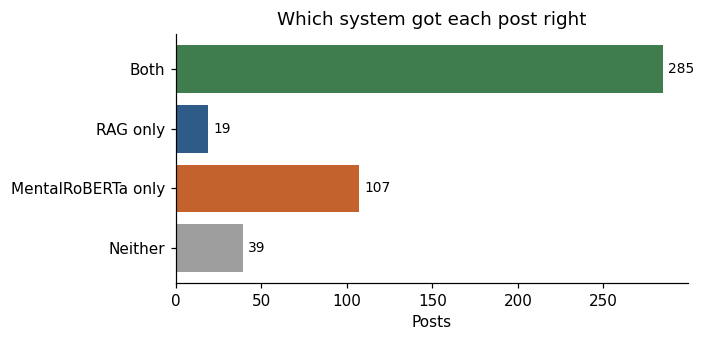

In [26]:
both  = int(((rag_correct == 1) & (mrb_correct == 1)).sum())
rag_o = int(((rag_correct == 1) & (mrb_correct == 0)).sum())
mrb_o = int(((rag_correct == 0) & (mrb_correct == 1)).sum())
none  = int(((rag_correct == 0) & (mrb_correct == 0)).sum())

print(f"both correct        : {both:3d}  ({both/len(y_true):.1%})")
print(f"RAG only correct    : {rag_o:3d}  ({rag_o/len(y_true):.1%})")
print(f"MRB only correct    : {mrb_o:3d}  ({mrb_o/len(y_true):.1%})")
print(f"neither correct     : {none:3d}  ({none/len(y_true):.1%})")
print(f"\nagreement on label  : {(systems['RAG pipeline (KB v2)'] == systems['MentalRoBERTa']).mean():.1%}")
print(f"oracle ceiling      : {(both + rag_o + mrb_o) / len(y_true):.1%}"
      "  (either system correct)")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.barh(["Both", "RAG only", "MentalRoBERTa only", "Neither"],
        [both, rag_o, mrb_o, none],
        color=["#3F7D4E", "#2E5B88", "#C4622D", "#9E9E9E"])
for i, v in enumerate([both, rag_o, mrb_o, none]):
    ax.text(v + 3, i, str(v), va="center", fontsize=9)
ax.set_xlabel("Posts")
ax.set_title("Which system got each post right")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Cost and qualitative trade-offs

Fill in the RAG latency from the Phase 9 run and the MentalRoBERTa inference
timing from the baseline script; both numbers are already recorded.

In [27]:
trade_offs = pd.DataFrame([
    {"Dimension": "Labelled data required", "RAG pipeline": "None for the classifier",
     "MentalRoBERTa": "~9,000 labelled posts"},
    {"Dimension": "Adaptation to new criteria", "RAG pipeline": "Edit the knowledge base",
     "MentalRoBERTa": "Re-train"},
    {"Dimension": "Output", "RAG pipeline": "Label + ICD-11 citation",
     "MentalRoBERTa": "Label + probability"},
    {"Dimension": "Auditability", "RAG pipeline": "Justification checkable against evidence",
     "MentalRoBERTa": "Opaque"},
    {"Dimension": "Model size", "RAG pipeline": "1.7B (generation) + 110M (embed)",
     "MentalRoBERTa": "125M"},
]).set_index("Dimension")
display(trade_offs)

,RAG pipeline,MentalRoBERTa
Dimension,,
Labelled data required,None for the classifier,"~9,000 labelled posts"
Adaptation to new criteria,Edit the knowledge base,Re-train
Output,Label + ICD-11 citation,Label + probability
Auditability,Justification checkable against evidence,Opaque
Model size,1.7B (generation) + 110M (embed),125M


## 8. Notes for the write-up

State plainly when reporting this comparison:

1. **The paradigms differ.** MentalRoBERTa is supervised on thousands of
   labelled posts from the same corpus and distribution as the evaluation set;
   the RAG pipeline uses no task-specific training. A supervised in-domain
   encoder is expected to be strong on in-distribution data — the interesting
   quantity is the size of the gap relative to what each approach costs and
   provides.
2. **Report the paired test, not overlapping intervals.** McNemar's exact test
   is the correct instrument here, and the discordant counts should be quoted.
3. **Report suicidal-class recall separately** from overall accuracy.
4. **Note the corpus limitation** already recorded in Section 3.10: the
   suicidal/depression distinction reflects the subreddit of origin rather than
   clinical judgement, which caps what either system's ceiling means clinically.
5. **State the licence.** MentalRoBERTa is CC BY-NC 4.0 (non-commercial) and
   gated — fine for academic evaluation, but it constrains any deployment claim.